# Experiment 3B: Hidden Per-Neuron Jitter (Shift) — SHD

## Overview

This notebook implements **Experiment 3B** from the "Beyond Beyond Rate"
project.

We train a single 2-hidden-layer SNN on the SHD dataset with **clean
(unperturbed) inputs**, then sweep per-neuron Gaussian shift at the
**1st hidden layer output during evaluation only**. This follows the
branch-wide train-clean / eval-perturbed protocol (see
`docs/progress/phase1to4_fixes.md`, Issue 1).

Unlike per-spike jitter (Exp 3A), a single Gaussian offset is drawn per
neuron and applied to **all** spikes from that neuron. This preserves
intra-neuron ISI patterns but disrupts cross-neuron (cross-channel)
timing relationships.

**Key question:** Does per-neuron shift at the hidden layer disrupt
SGD-delay more than SGD? If so, cross-channel timing is maintained
internally — not just at the input.

### Workflow

1. Load SHD dataset (whole / part / norm, selected via global config).
2. Train a single SNN on **clean** inputs (one per `(DATASET_KEY, USE_DELAY)`).
3. Evaluate the trained model with hidden-layer per-neuron shift across
   the sigma sweep, with repeated test runs for error bars.
4. Plot accuracy vs. sigma and save results.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../../temporal_shd_project/code/src"))
import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here. Toggle `USE_DELAY`
to switch between SGD-delay and SGD (no delay) mode. Set `DATASET_KEY`
to choose which SHD variant to use.

In [2]:
# =====================================================================
# When True: train one model for every combination of DATASET_KEY in
# ("whole", "part", "norm") × USE_DELAY in (False, True) — six cells of
# the grid. The single (DATASET_KEY, USE_DELAY) below is used as the
# default config when this flag is False; under the grid it is ignored
# by the run loop.
# =====================================================================
train_all_variation: bool = True

# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay)
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm"
# =====================================================================
DATASET_KEY: str = "norm"

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "../../realistic/shd/shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "../../realistic/shd/shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "../../realistic/shd/shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
EPOCHS: int = 1250
BATCH_SIZE: int = 128
LEARNING_RATE: float = 0.1
SEED: int = 42
MAX_DELAY: int = 64
EARLY_STOP_PATIENCE: int = 300

# --- Per-neuron shift sweep: sigma values in ms ---
SIGMA_VALUES: list[int] = [0, 1, 3, 5, 10, 17, 25]

# --- Evaluation ---
NUM_REPEATS: int = 3

# --- Derived names (default config; the grid loop derives its own per cell) ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"shift_{DATASET_KEY}_{DELAY_TAG}"

print(f"train_all_variation = {train_all_variation}")
print(f"Default dataset: SHD {DATASET_KEY} | Input dim: {INPUT_DIM}")
print(f"Default network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
print(f"Default model prefix: {MODEL_PREFIX}")
print(f"Sigma sweep: {SIGMA_VALUES}")

train_all_variation = True
Default dataset: SHD norm | Input dim: 224
Default network mode: SGD (no delay)
Default model prefix: shift_norm_nodelay
Sigma sweep: [0, 1, 3, 5, 10, 17, 25]


## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(neurons, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [3]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


## 4. Per-Neuron Jitter (Shift) Utility

The core perturbation function for Experiment 3B. For each neuron, a single
Gaussian offset is drawn from N(0, sigma) and applied to **all** spikes of
that neuron. This preserves the intra-neuron inter-spike intervals (ISI)
but disrupts cross-neuron timing relationships within the hidden layer.

Shifted spike times are clipped to `[0, T-1]`.

In [4]:
def shift_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
) -> np.ndarray:
    """Apply per-neuron Gaussian shift to a binary spike train.

    For each neuron, a single offset ~ N(0, sigma) is drawn and all spikes
    from that neuron are shifted by this offset. Shifted times are clipped
    to [0, T-1] and duplicates from clipping are merged (spike count may
    decrease slightly at boundaries).

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        sigma: Standard deviation of the Gaussian shift (in time steps / ms).

    Returns:
        Shifted spike train with same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue

        # Single offset per neuron — preserves intra-neuron ISI
        d = int(round(np.random.normal(0, sigma)))
        shifted_times = np.clip(spike_times + d, 0, T - 1)
        shifted_times = np.unique(shifted_times)

        new_train[neuron_idx, shifted_times] = 1

    return new_train


def shift_hidden_batch(
    hidden_spikes: torch.Tensor,
    sigma: float,
) -> torch.Tensor:
    """Apply per-neuron shift to a batch of hidden spike tensors.

    Converts from SLAYER's 5-D format (B, C, 1, 1, T) to numpy,
    shifts each sample, and converts back.

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).
        sigma: Shift standard deviation in ms.

    Returns:
        Shifted spike tensor with same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.detach().cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = shift_spike_train(sample, sigma)

    return torch.from_numpy(spikes_np).to(dev)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. All splits use **unperturbed** input data — the per-neuron shift is applied
at the hidden layer inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture:

```
Input -> [PSP + fc1 + spike] -> hidden1 spikes
                                      ↓
              ← per-neuron shift applied here at eval time
                                      ↓
        -> (delay1) -> [PSP + fc2 + spike] -> (delay2)
        -> [PSP + fc3 + spike] -> output
```

Two forward methods are provided:

- `forward(x)`: clean pass used during training (no shift).
- `forward_with_hidden_perturbation(x, sigma)`: intercepts the 1st hidden
  layer spike output, applies per-neuron shift, then continues to the
  rest of the network. Called only from eval loops inside
  `torch.no_grad()` — the numpy round-trip in `shift_hidden_batch`
  therefore never participates in autograd.

Delays are applied at the start of `_second_hidden_and_output` rather than
at the end of `_first_hidden`, so the perturbation hook sees raw binary
spikes (see Issue 2 in `docs/progress/phase1to4_fixes.md`).

In [6]:
class ShiftSHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN with optional per-neuron shift at the 1st hidden layer.

    Two forward paths:
    - ``forward(x)``: clean pass used during training (no shift).
    - ``forward_with_hidden_perturbation(x, sigma)``: intercepts the
      1st hidden layer spike output, applies per-neuron shift, then
      continues to the rest of the network. Called only from eval loops
      inside ``torch.no_grad()``.

    The ``delay1`` layer is applied at the start of
    ``_second_hidden_and_output`` (not at the end of ``_first_hidden``),
    so the perturbation hook sees raw binary spikes from fc1.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike. Returns raw binary hidden1 spikes (pre-delay)."""
        return self.slayer.spike(self.fc1(self.slayer.psp(x)))

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """(delay1) -> hidden1 -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        if self.use_delay:
            hidden1 = self.delay1(hidden1)
        x = self.slayer.spike(self.fc2(self.slayer.psp(hidden1)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Clean forward pass — no shift. Used during training."""
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        return self._second_hidden_and_output(hidden1)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        sigma: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with per-neuron shift at the 1st hidden layer.

        Call only from eval loops inside ``torch.no_grad()`` — the numpy
        round-trip in ``shift_hidden_batch`` is not autograd-safe.

        Args:
            x: Input spike trains.
            sigma: Per-neuron shift std dev in ms. 0 means no shift (identity).

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if sigma > 0:
            hidden1 = shift_hidden_batch(hidden1, sigma)

        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train a single model on **clean (unperturbed) inputs** — per-neuron shift
is not applied during training or in-training validation. Uses SLAYER's
`NumSpikes` loss with the Nadam optimiser and adaptive delay clamping
(matching the original SHD training script).

In [7]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: ShiftSHDNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build NumSpikes loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    input_dim: int = INPUT_DIM,
    hidden_units: int = HIDDEN_UNITS,
    num_classes: int = NUM_CLASSES,
    use_delay: bool = USE_DELAY,
    max_delay: int = MAX_DELAY,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    seed: int = SEED,
    patience: int = EARLY_STOP_PATIENCE,
) -> tuple[ShiftSHDNetwork, dict]:
    """Train a ShiftSHDNetwork on unperturbed inputs.

    Trains a single model using clean forward passes. Per-neuron shift
    is applied only at evaluation time via
    ``forward_with_hidden_perturbation``.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed.
        patience: Early stopping patience.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = ShiftSHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training (clean)") as pbar:
        for epoch in range(epochs):
            # --- Train (clean forward) ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                outputs = net(x_batch)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate (clean forward — no perturbation) ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing with Hidden-Layer Per-Neuron Shift

Evaluate the (single, clean-trained) model on the test set by sweeping
per-neuron shift sigma values. Each call goes through
`forward_with_hidden_perturbation` inside `torch.no_grad()`. Repeated
evaluations with different random seeds provide error bars.

In [8]:
def test_with_shift(
    net: ShiftSHDNetwork,
    test_loader: DataLoader,
    sigma: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer per-neuron shift at level sigma.

    Args:
        net: Trained ShiftSHDNetwork.
        test_loader: Test DataLoader.
        sigma: Per-neuron shift std dev applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, sigma=sigma)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: ShiftSHDNetwork,
    test_loader: DataLoader,
    sigma: float,
    num_repeats: int = NUM_REPEATS,
) -> dict:
    """Evaluate with per-neuron shift multiple times for error bars.

    Args:
        net: Trained network.
        test_loader: Test DataLoader.
        sigma: Per-neuron shift std dev.
        num_repeats: Number of independent evaluations.

    Returns:
        Dict with "mean", "std", and "values".
    """
    accuracies = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        acc = test_with_shift(net, test_loader, sigma=sigma)
        accuracies.append(acc)

    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": accuracies,
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. shift sigma across all trained models (the main result).

In [9]:
def plot_training_curves(
    log: dict,
    dataset_key: str | None = None,
    delay_tag: str | None = None,
) -> None:
    """Plot training / validation loss, accuracy, and delay evolution.

    Args:
        log: Training-log dict produced by ``train_model``.
        dataset_key: SHD variant for the title (defaults to module-level
            ``DATASET_KEY``).
        delay_tag: "delay" / "nodelay" for the title (defaults to module-level
            ``DELAY_TAG``).
    """
    dk = dataset_key if dataset_key is not None else DATASET_KEY
    dt = delay_tag if delay_tag is not None else DELAY_TAG

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SHD {dk} ({dt}) — Training (clean inputs)", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_shift_sweep_curve(
    sweep_results: dict[int, dict],
    dataset_key: str | None = None,
    delay_tag: str | None = None,
    use_delay: bool | None = None,
    model_prefix: str | None = None,
) -> None:
    """Plot accuracy vs hidden per-neuron shift sigma for the trained model.

    Args:
        sweep_results: Mapping sigma -> {"mean", "std", "values"}.
        dataset_key: SHD variant (defaults to module-level ``DATASET_KEY``).
        delay_tag: "delay" / "nodelay" (defaults to module-level ``DELAY_TAG``).
        use_delay: Network variant flag (defaults to module-level ``USE_DELAY``).
        model_prefix: Filename prefix for the saved figure (defaults to
            module-level ``MODEL_PREFIX``).
    """
    dk = dataset_key if dataset_key is not None else DATASET_KEY
    dt = delay_tag if delay_tag is not None else DELAY_TAG
    ud = use_delay if use_delay is not None else USE_DELAY
    mp = model_prefix if model_prefix is not None else MODEL_PREFIX

    sigma_vals = sorted(sweep_results.keys())
    means = [sweep_results[s]["mean"] for s in sigma_vals]
    stds = [sweep_results[s]["std"] for s in sigma_vals]

    color = "tab:orange" if ud else "tab:blue"
    label = f"SGD-delay ({dk})" if ud else f"SGD ({dk})"

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        sigma_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Per-Neuron Shift Sigma (ms)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 3B: SHD {dk} — Accuracy vs Hidden Per-Neuron Shift ({dt})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for s, mean, std in zip(sigma_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (s, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = f"log/{mp}_shift_sweep.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train Once, then Sweep Per-Neuron Shift at Eval Time

When `train_all_variation = False` (default), train a single model on
clean inputs for the `(DATASET_KEY, USE_DELAY)` configuration selected at
the top and sweep the per-neuron shift sigma at evaluation time.

When `train_all_variation = True`, the loop iterates over **all six**
combinations of dataset ∈ {whole, part, norm} × use_delay ∈ {False, True},
training one model per cell, saving its `{model_prefix}_trained.pt`
checkpoint, and running the shift sweep on it. Results are accumulated
in `all_runs[(dataset_key, use_delay)]` so the downstream plot / save /
analysis cells iterate over every configuration.

In [10]:
os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

# Build the configuration grid. When train_all_variation is True we sweep all
# (dataset, use_delay) combinations; otherwise we run the single default
# config picked at the top of the notebook.
if train_all_variation:
    config_grid: list[tuple[str, bool]] = [
        (dk, ud) for dk in DATASET_CONFIGS for ud in (False, True)
    ]
else:
    config_grid = [(DATASET_KEY, USE_DELAY)]

print(f"Running {len(config_grid)} configuration(s): {config_grid}")

all_runs: dict[tuple[str, bool], dict] = {}

for dataset_key, use_delay in config_grid:
    input_dim = DATASET_CONFIGS[dataset_key]["input_dim"]
    mat_file = DATASET_CONFIGS[dataset_key]["mat_file"]
    delay_tag = "delay" if use_delay else "nodelay"
    model_prefix = f"shift_{dataset_key}_{delay_tag}"

    print(f"\n{'#'*70}")
    print(f"#  Configuration: dataset={dataset_key} | {delay_tag}")
    print(f"{'#'*70}")

    # Load dataset for this configuration
    X_cfg, Y_cfg = load_shd_data(mat_file, target_T=SIM_PARAMS["tSample"])
    train_loader, val_loader, test_loader = build_dataloaders(
        X_cfg, Y_cfg, batch_size=BATCH_SIZE, seed=SEED
    )

    # Train a single model on clean inputs
    print(f"\n  --- Training (clean inputs, {delay_tag}) ---")
    cfg_net, cfg_training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        input_dim=input_dim,
        use_delay=use_delay,
    )

    # Save the trained model
    model_path = f"data/{model_prefix}_trained.pt"
    torch.save(cfg_net.state_dict(), model_path)
    print(f"\n  Model saved to {model_path}")

    # Evaluate across the per-neuron shift sweep
    print(f"\n  --- Hidden per-neuron shift sweep at evaluation ---")
    cfg_test_results: dict[int, dict] = {}
    for sigma in SIGMA_VALUES:
        test_result = test_with_repeats(cfg_net, test_loader, sigma=sigma)
        cfg_test_results[sigma] = test_result
        print(
            f"    sigma={sigma:3d} ms | "
            f"accuracy = {test_result['mean']:.4f} +/- {test_result['std']:.4f}"
        )

    all_runs[(dataset_key, use_delay)] = {
        "net": cfg_net,
        "training_log": cfg_training_log,
        "all_test_results": cfg_test_results,
        "dataset_key": dataset_key,
        "use_delay": use_delay,
        "delay_tag": delay_tag,
        "model_prefix": model_prefix,
    }

# Expose the last run's results under the names that the downstream
# single-config cells expect, for back-compat.
_last = list(all_runs.values())[-1]
net = _last["net"]
training_log = _last["training_log"]
all_test_results = _last["all_test_results"]

Running 6 configuration(s): [('whole', False), ('whole', True), ('part', False), ('part', True), ('norm', False), ('norm', True)]

######################################################################
#  Configuration: dataset=whole | nodelay
######################################################################
Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_whole.mat: X=(9984, 700, 200), Y=(9984,), classes=20
Train: 5990 | Val: 1498 | Test: 1497

  --- Training (clean inputs, nodelay) ---


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training (clean):   0%|          | 0/58750 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training (clean): 100%|██████████| 58750/58750 [1:59:22<00:00,  8.20it/s, acc=68.42%, delay=0.0, epoch=1250, train=241.271, val=281.657]  



  Model saved to data/shift_whole_nodelay_trained.pt

  --- Hidden per-neuron shift sweep at evaluation ---
    sigma=  0 ms | accuracy = 0.5718 +/- 0.0000
    sigma=  1 ms | accuracy = 0.5449 +/- 0.0107
    sigma=  3 ms | accuracy = 0.4398 +/- 0.0078
    sigma=  5 ms | accuracy = 0.3721 +/- 0.0024
    sigma= 10 ms | accuracy = 0.2768 +/- 0.0064
    sigma= 17 ms | accuracy = 0.2035 +/- 0.0061
    sigma= 25 ms | accuracy = 0.1574 +/- 0.0115

######################################################################
#  Configuration: dataset=whole | delay
######################################################################
Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_whole.mat: X=(9984, 700, 200), Y=(9984,), classes=20


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Train: 5990 | Val: 1498 | Test: 1497

  --- Training (clean inputs, delay) ---


...


  Model saved to data/shift_part_delay_trained.pt

  --- Hidden per-neuron shift sweep at evaluation ---
    sigma=  0 ms | accuracy = 0.7399 +/- 0.0000
    sigma=  1 ms | accuracy = 0.7184 +/- 0.0055
    sigma=  3 ms | accuracy = 0.5832 +/- 0.0071
    sigma=  5 ms | accuracy = 0.4330 +/- 0.0075
    sigma= 10 ms | accuracy = 0.2584 +/- 0.0100
    sigma= 17 ms | accuracy = 0.1872 +/- 0.0097
    sigma= 25 ms | accuracy = 0.1559 +/- 0.0141

######################################################################
#  Configuration: dataset=norm | nodelay
######################################################################
Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_norm_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20
Train: 3276 | Val: 819 | Test: 819

  --- Training (clean inputs, nodelay) ---


Training (clean):  55%|█████▍    | 17758/32500 [30:43<25:30,  9.63it/s, acc=20.02%, delay=0.0, epoch=683, train=346.941, val=344.358] 



Early stopping at epoch 683

  Model saved to data/shift_norm_nodelay_trained.pt

  --- Hidden per-neuron shift sweep at evaluation ---
    sigma=  0 ms | accuracy = 0.2418 +/- 0.0000
    sigma=  1 ms | accuracy = 0.2173 +/- 0.0053
    sigma=  3 ms | accuracy = 0.1689 +/- 0.0092
    sigma=  5 ms | accuracy = 0.1453 +/- 0.0050
    sigma= 10 ms | accuracy = 0.1066 +/- 0.0015
    sigma= 17 ms | accuracy = 0.0794 +/- 0.0000
    sigma= 25 ms | accuracy = 0.0704 +/- 0.0047

######################################################################
#  Configuration: dataset=norm | delay
######################################################################
Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_norm_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20
Train: 3276 | Val: 819 | Test: 819

  --- Training (clean inputs, delay) ---


Training (clean): 100%|██████████| 32500/32500 [1:01:31<00:00,  8.80it/s, acc=45.91%, delay=31.9, epoch=1250, train=263.297, val=282.975]



  Model saved to data/shift_norm_delay_trained.pt

  --- Hidden per-neuron shift sweep at evaluation ---
    sigma=  0 ms | accuracy = 0.5299 +/- 0.0000
    sigma=  1 ms | accuracy = 0.5002 +/- 0.0058
    sigma=  3 ms | accuracy = 0.3618 +/- 0.0130
    sigma=  5 ms | accuracy = 0.2454 +/- 0.0043
    sigma= 10 ms | accuracy = 0.1506 +/- 0.0006
    sigma= 17 ms | accuracy = 0.1217 +/- 0.0076
    sigma= 25 ms | accuracy = 0.1070 +/- 0.0021


## 11. Plot Training Curves

Show training curves for the single clean-trained model.


--- Training curves: dataset=whole, nodelay ---


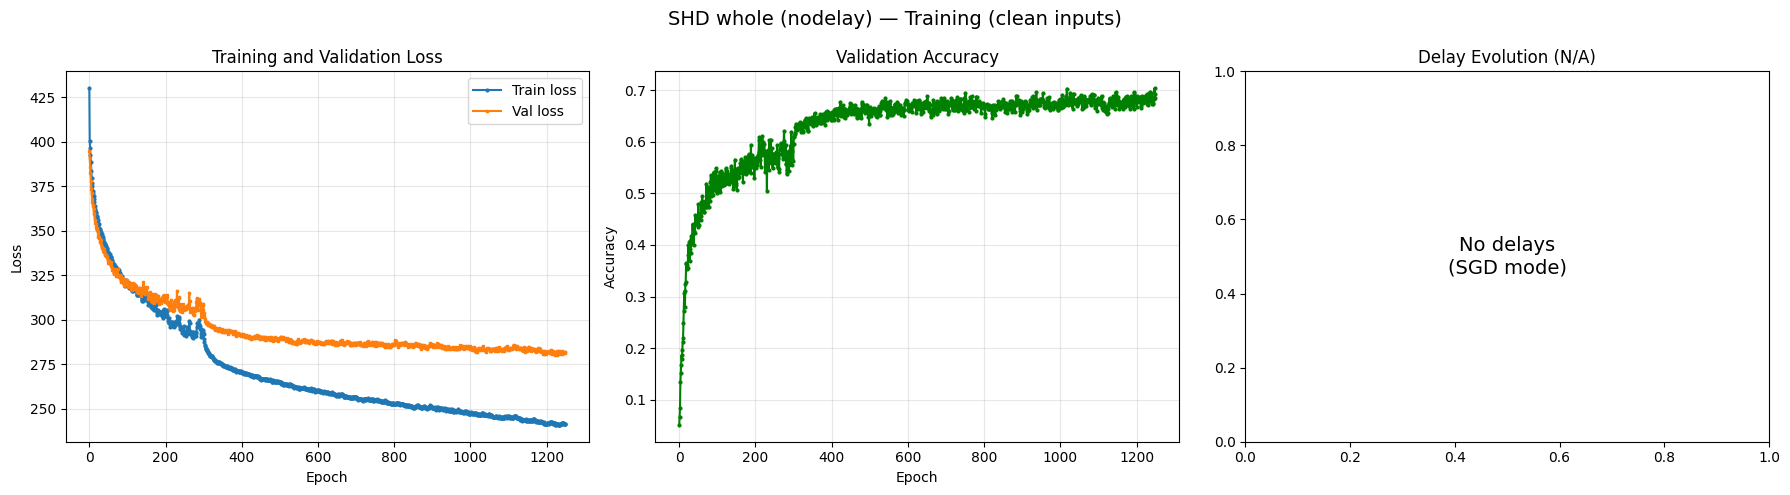


--- Training curves: dataset=whole, delay ---


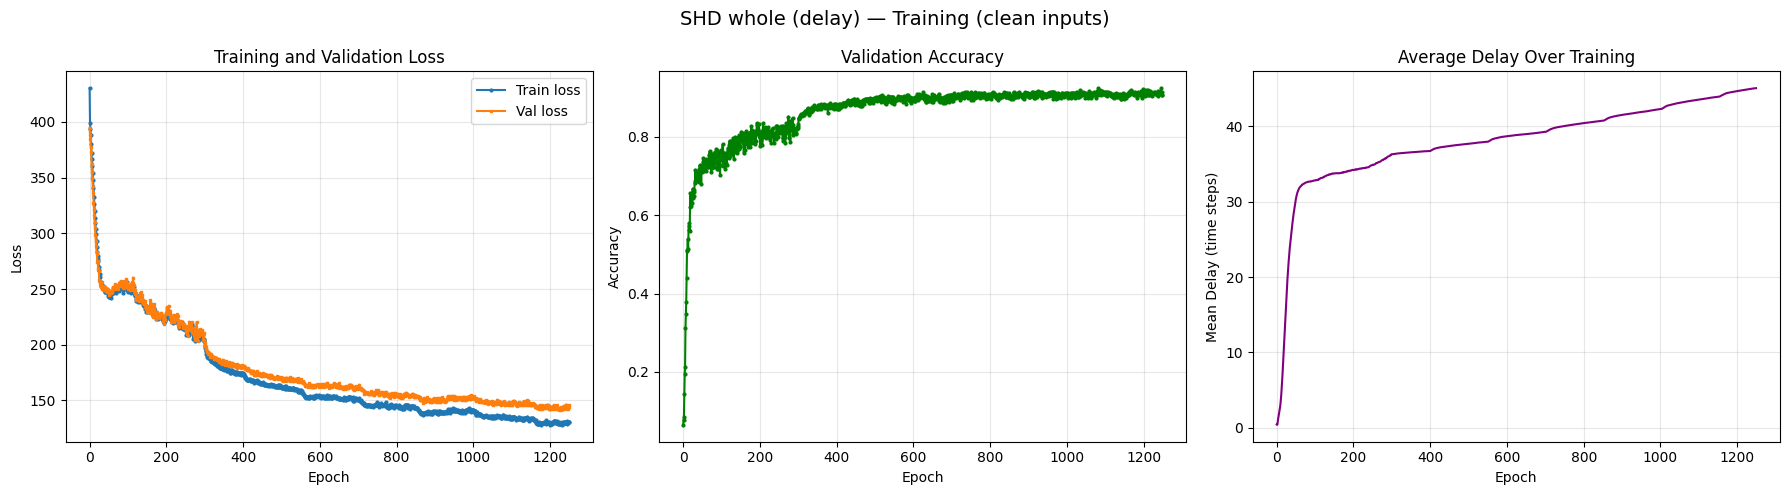


--- Training curves: dataset=part, nodelay ---


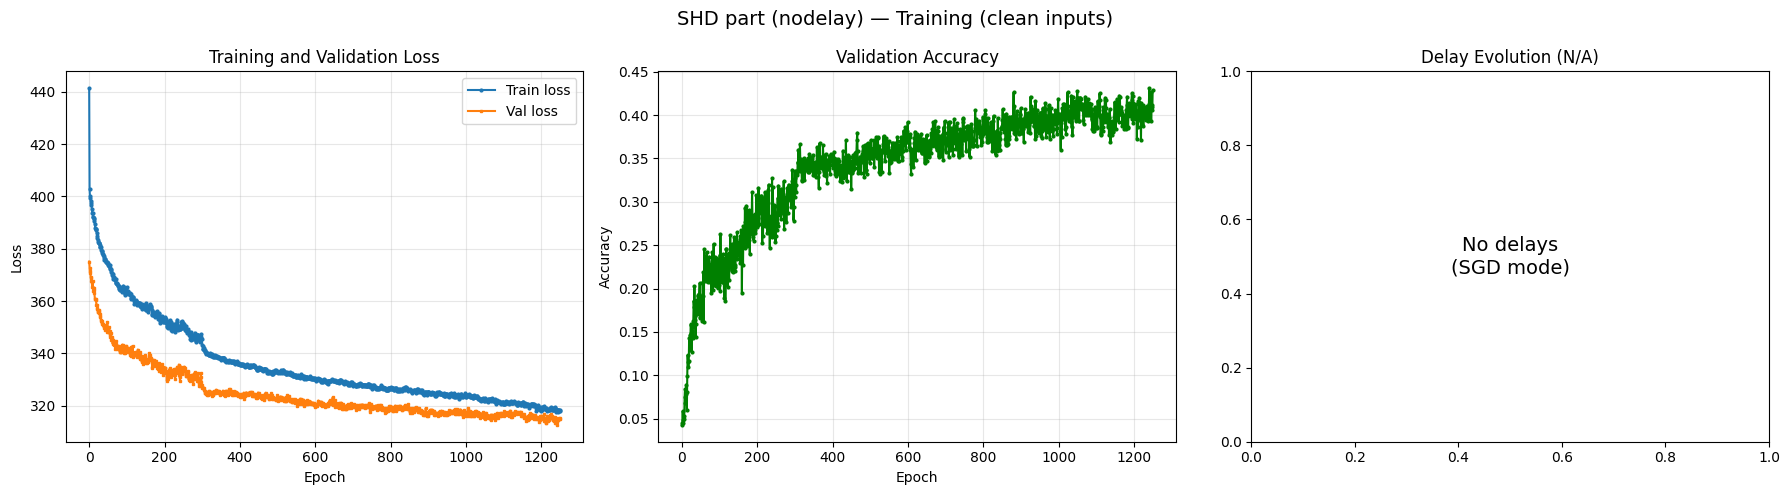


--- Training curves: dataset=part, delay ---


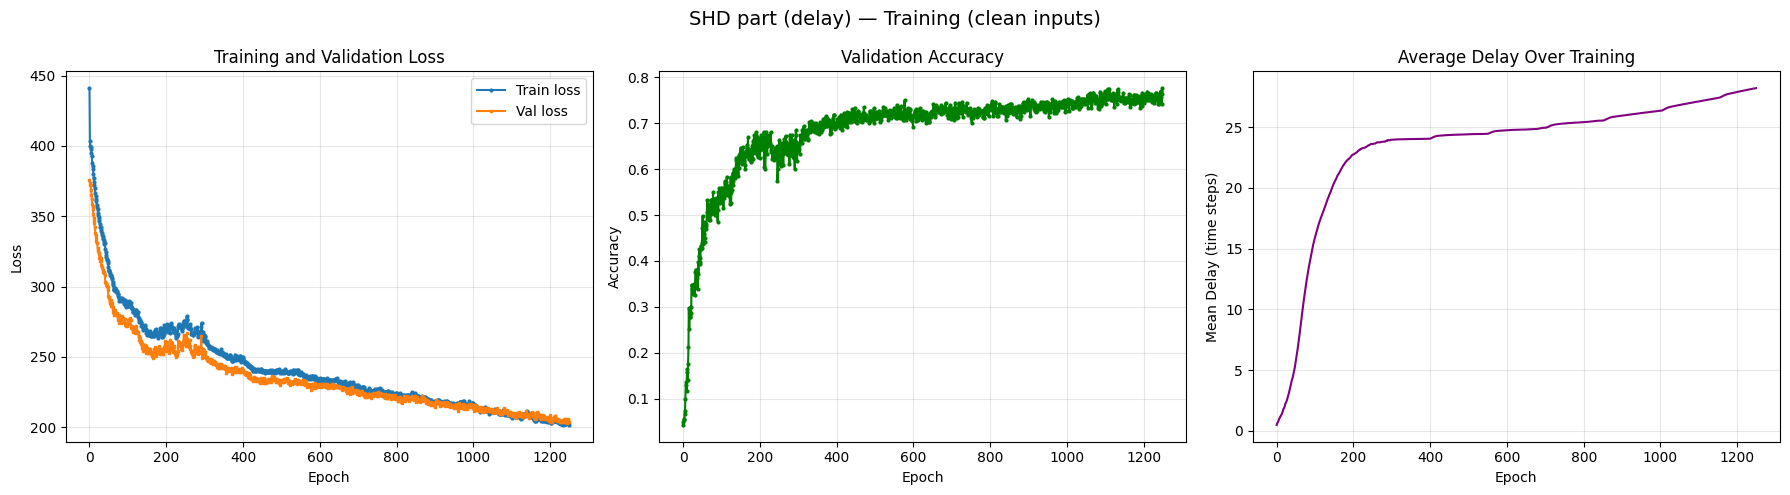


--- Training curves: dataset=norm, nodelay ---


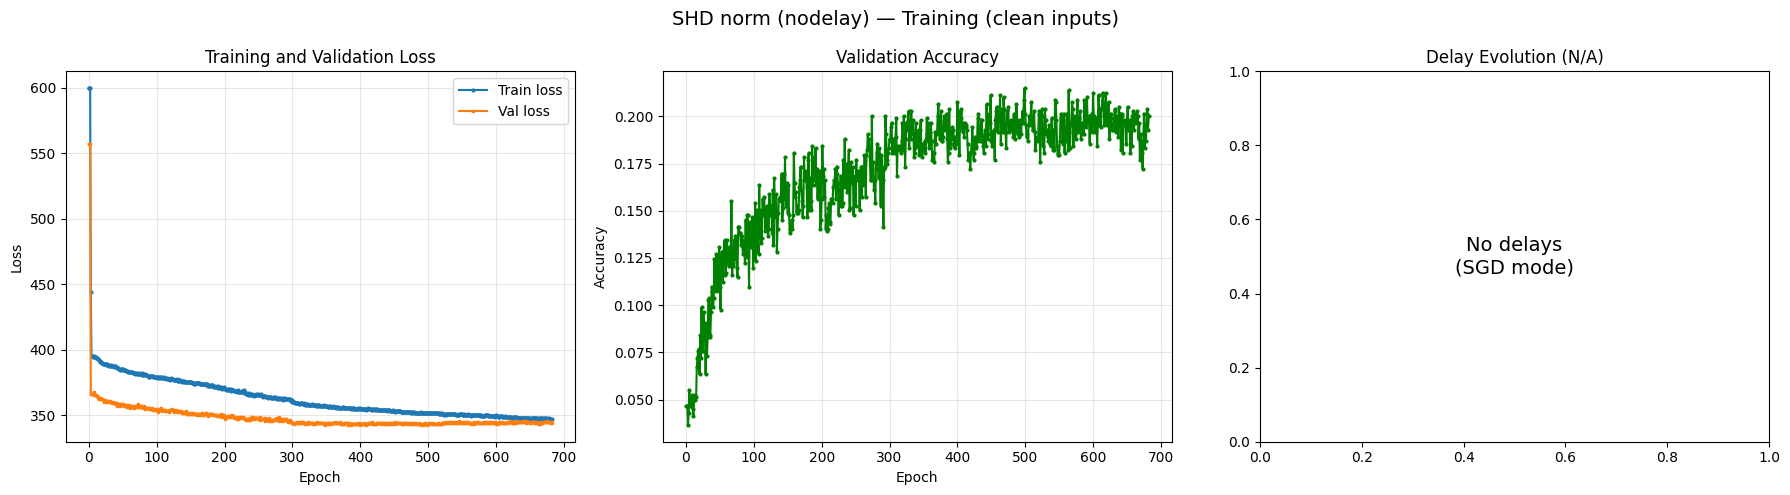


--- Training curves: dataset=norm, delay ---


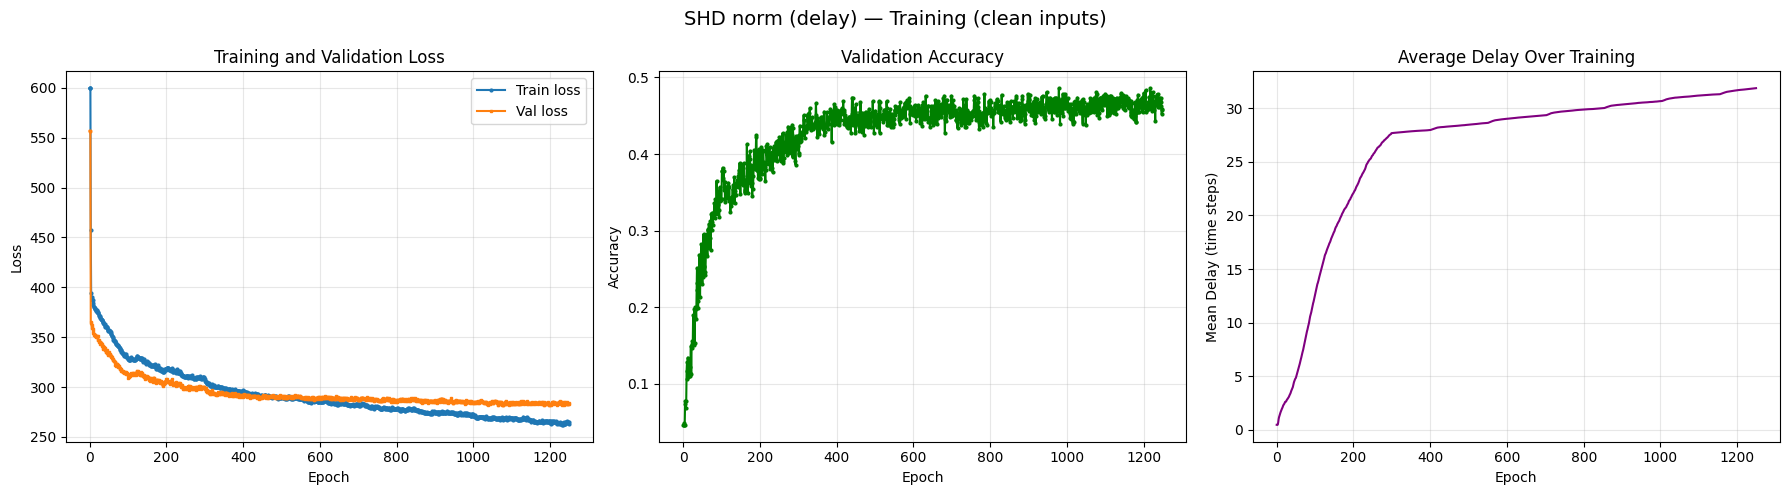

In [11]:
for (_dk, _ud), _run in all_runs.items():
    print(f"\n--- Training curves: dataset={_dk}, {_run['delay_tag']} ---")
    plot_training_curves(
        _run["training_log"],
        dataset_key=_dk,
        delay_tag=_run["delay_tag"],
    )

## 12. Plot Per-Neuron Shift Sweep Results

The main result: test accuracy vs. hidden-layer per-neuron shift sigma
evaluated on the single clean-trained model.


--- Sweep curve: dataset=whole, nodelay ---


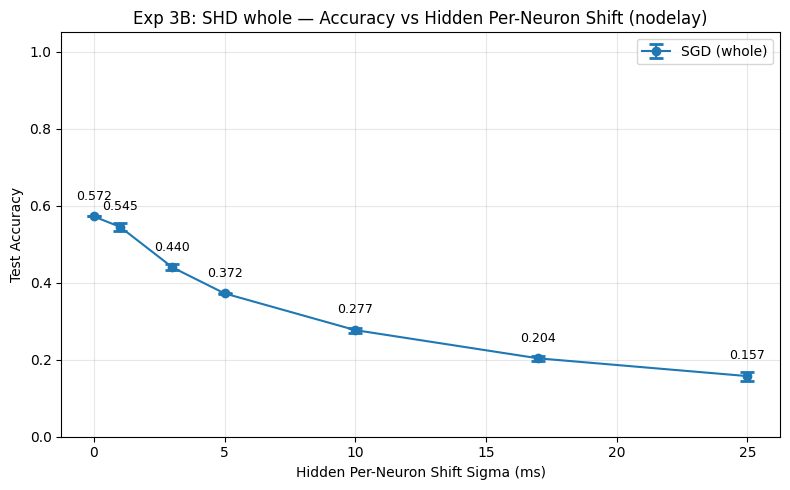

Figure saved to log/shift_whole_nodelay_shift_sweep.png

--- Sweep curve: dataset=whole, delay ---


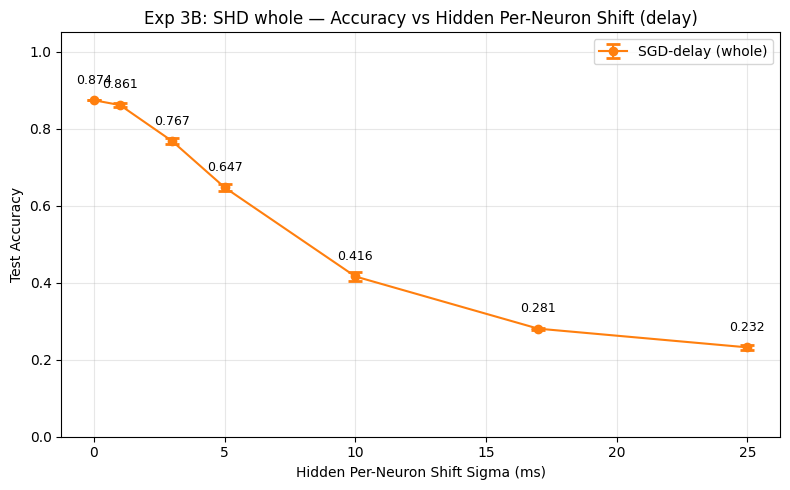

Figure saved to log/shift_whole_delay_shift_sweep.png

--- Sweep curve: dataset=part, nodelay ---


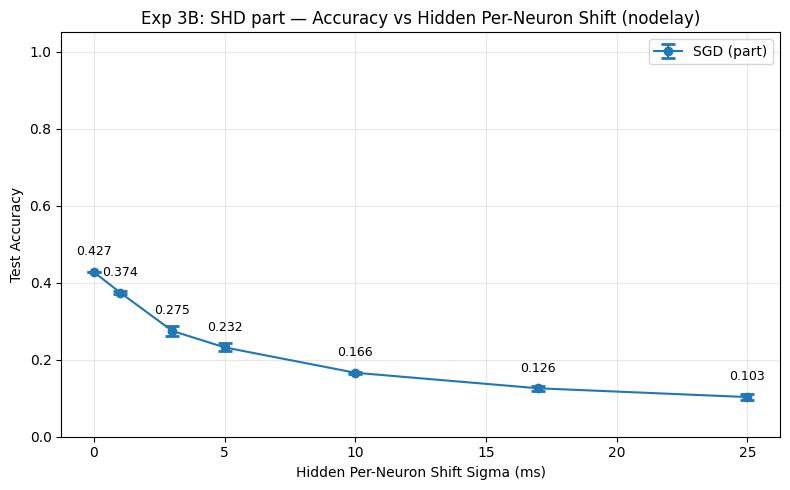

Figure saved to log/shift_part_nodelay_shift_sweep.png

--- Sweep curve: dataset=part, delay ---


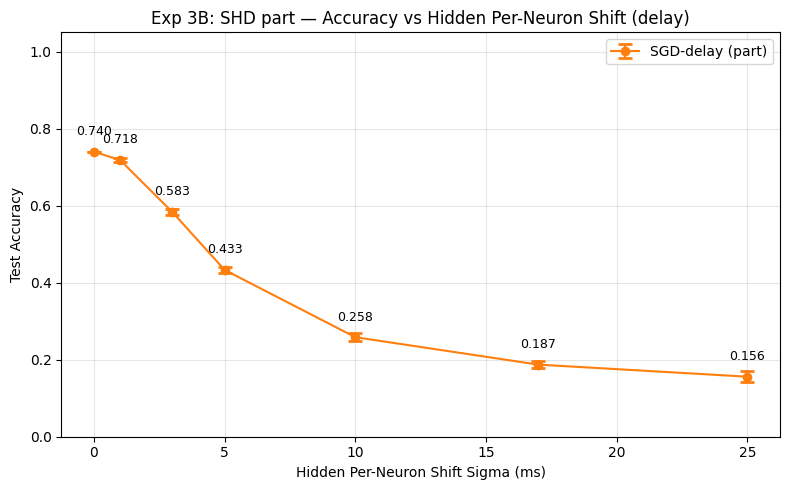

Figure saved to log/shift_part_delay_shift_sweep.png

--- Sweep curve: dataset=norm, nodelay ---


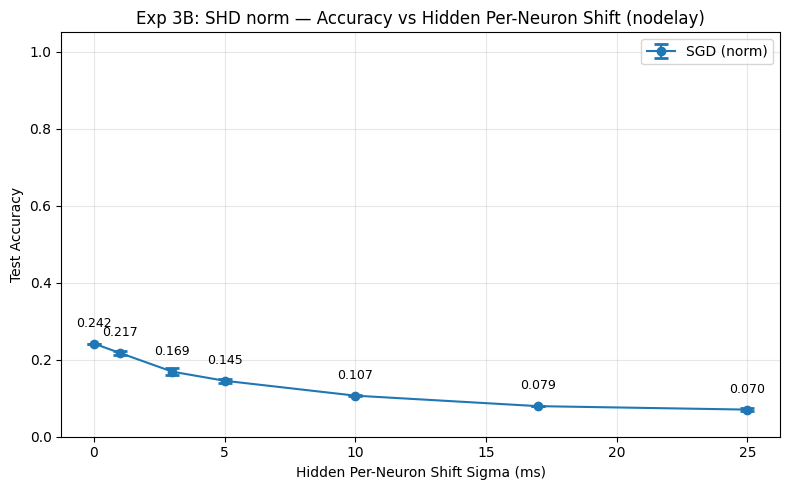

Figure saved to log/shift_norm_nodelay_shift_sweep.png

--- Sweep curve: dataset=norm, delay ---


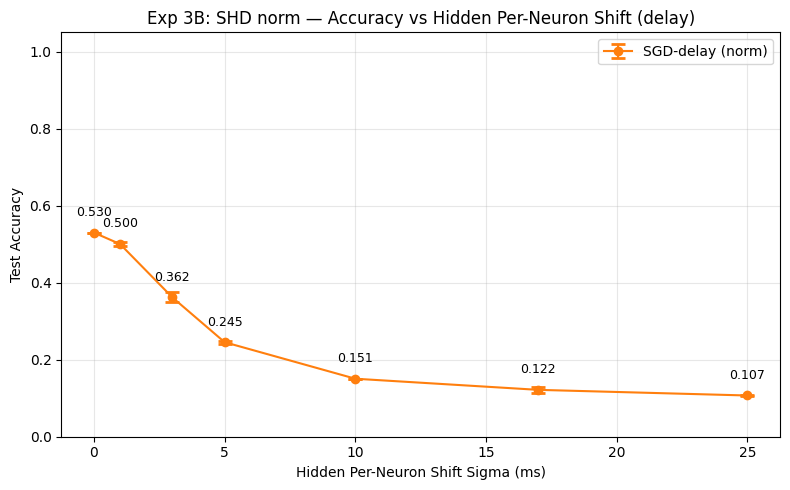

Figure saved to log/shift_norm_delay_shift_sweep.png


In [12]:
for (_dk, _ud), _run in all_runs.items():
    print(f"\n--- Sweep curve: dataset={_dk}, {_run['delay_tag']} ---")
    plot_shift_sweep_curve(
        _run["all_test_results"],
        dataset_key=_dk,
        delay_tag=_run["delay_tag"],
        use_delay=_ud,
        model_prefix=_run["model_prefix"],
    )

## 13. Save Results

Save the sweep results and all training logs to JSON for later comparison
across dataset variants and delay/no-delay modes.

In [13]:
for (_dk, _ud), _run in all_runs.items():
    _mp = _run["model_prefix"]

    # Save sweep results
    sweep_serialisable = {
        str(sigma): {
            "mean": data["mean"],
            "std": data["std"],
            "values": [float(v) for v in data["values"]],
        }
        for sigma, data in _run["all_test_results"].items()
    }
    results_path = f"log/{_mp}_shift_sweep_results.json"
    with open(results_path, "w") as fp:
        json.dump(sweep_serialisable, fp, indent=2)
    print(f"Sweep results saved to {results_path}")

    # Save the training log
    log_path = f"log/{_mp}_training_log.json"
    log_serialisable = {
        k: [float(v) for v in vals] if isinstance(vals, list) else vals
        for k, vals in _run["training_log"].items()
    }
    with open(log_path, "w") as fp:
        json.dump(log_serialisable, fp, indent=2)
    print(f"Training log saved to {log_path}")

Sweep results saved to log/shift_whole_nodelay_shift_sweep_results.json
Training log saved to log/shift_whole_nodelay_training_log.json
Sweep results saved to log/shift_whole_delay_shift_sweep_results.json
Training log saved to log/shift_whole_delay_training_log.json
Sweep results saved to log/shift_part_nodelay_shift_sweep_results.json
Training log saved to log/shift_part_nodelay_training_log.json
Sweep results saved to log/shift_part_delay_shift_sweep_results.json
Training log saved to log/shift_part_delay_training_log.json
Sweep results saved to log/shift_norm_nodelay_shift_sweep_results.json
Training log saved to log/shift_norm_nodelay_training_log.json
Sweep results saved to log/shift_norm_delay_shift_sweep_results.json
Training log saved to log/shift_norm_delay_training_log.json


## 14. Model Analysis

Print delay statistics and weight statistics for the trained model.

In [14]:
for (_dk, _ud), _run in all_runs.items():
    print(f"\n{'='*60}")
    print(f"  Model Analysis: dataset={_dk}, {_run['delay_tag']}")
    print(f"{'='*60}")
    _cfg_net = _run["net"]

    delays = _cfg_net.get_delays()
    if delays:
        for delay_name, delay_values in delays.items():
            if len(delay_values) > 0:
                print(
                    f"  {delay_name}: "
                    f"mean={np.mean(delay_values):.2f}, "
                    f"std={np.std(delay_values):.2f}, "
                    f"min={np.min(delay_values):.2f}, "
                    f"max={np.max(delay_values):.2f}"
                )
    else:
        print("  No delays (SGD mode)")

    for name, param in _cfg_net.named_parameters():
        if "weight" in name:
            w = param.data
            print(
                f"  {name}: mean={w.mean().item():.4f}, "
                f"std={w.std().item():.4f}, "
                f"shape={list(w.shape)}"
            )


  Model Analysis: dataset=whole, nodelay
  No delays (SGD mode)
  fc1.weight_g: mean=41.2102, std=28.9327, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.8633, std=10.8160, shape=[128, 700, 1, 1, 1]
  fc2.weight_g: mean=56.7564, std=70.2555, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.2384, std=6.3992, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=222.0486, std=44.5977, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=-0.4169, std=7.4907, shape=[20, 128, 1, 1, 1]

  Model Analysis: dataset=whole, delay
  delay1: mean=49.94, std=27.23, min=0.00, max=70.00
  delay2: mean=39.85, std=32.29, min=0.00, max=70.00
  fc1.weight_g: mean=48.4226, std=37.2010, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=0.7628, std=10.7967, shape=[128, 700, 1, 1, 1]
  fc2.weight_g: mean=77.8963, std=78.2740, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.3251, std=6.9630, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=314.8609, std=43.4008, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=-1.4476, std=8.1595, shape